# Analysis of image grouping using tSNE (2023)

###### all-MiniLM-L6-v3 + iPCA

In [1]:
import pandas as pd
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

## 1. Preprocess title embeddings for tSNE
###### r=0.82

In [ ]:
df_emb = pd.read_csv('../../../Amazon_Sports_and_Outdoors/Amazon_Sports_and_Outdoors.image', sep='\t')
df_emb.head(5)

,img_id:token,img_emb:float_seq
0,884509,2.116241893624543 -3.0418755567230007 -5.46931...
1,561856,1.649818936829127 3.1124404940420742 2.8051456...
2,239749,-1.578862879367632 -4.014066168838383 0.149213...
3,55030,3.093842411693621 -1.7237219859956285 -0.78452...
4,1277121,-1.2830992703265296 5.067334132483662 1.839873...


In [3]:
df_emb.rename(columns={"img_emb:float_seq": "emb", "img_id:token": "id"}, inplace=True)
df_emb["emb"] = df_emb["emb"].apply(lambda x: np.fromstring(x, dtype=np.float32, sep=' '))
df_emb.head(5)

,id,emb
0,884509,"[2.116242, -3.0418756, -5.469318, 0.9049815, -..."
1,561856,"[1.6498189, 3.1124406, 2.8051457, -1.02009, -1..."
2,239749,"[-1.5788629, -4.014066, 0.14921321, 1.5560805,..."
3,55030,"[3.0938425, -1.723722, -0.78452605, -1.4718788..."
4,1277121,"[-1.2830993, 5.067334, 1.8398732, 0.92253864, ..."


In [ ]:
df_cat = pd.read_csv('../../../Amazon_Sports_and_Outdoors/Amazon_Sports_and_Outdoors.item', sep='\t')
df_cat.head(5)

,item_id:token,title:token,price:float,brand:token,categories:token_seq,sales_type:token,sales_rank:float
0,884509,Sure-Grip Zombie Wheels Low 59mm 4 Pack,55.00,Sure-Grip,"'Sports & Outdoors', 'Sports', 'Skates, Skateb...",Sports & Outdoors,295175.0
1,561856,USGI Wet Weather Bag (Fоur Paсk),NaN,USGI,"'Sports & Outdoors', 'Sports', 'Boating & Sail...",Sports & Outdoors,962400.0
2,239749,NHL San Jose Sharks Team Logo Post Earrings,18.99,Aminco,"'Sports & Outdoors', 'Fan Shop', 'Jewelry & Wa...",Sports & Outdoors,721263.0
3,55030,Bont Skates - Prostar Purple Suede Professiona...,209.00,Bont,"'Sports & Outdoors', 'Sports', 'Skates, Skateb...",Sports & Outdoors,213685.0
4,1277121,Team Golf Alamaba Crimson Tide Embroidered Tow...,NaN,Team Golf,"'Sports & Outdoors', 'Fan Shop', 'Sports Equip...",Sports & Outdoors,1621084.0


In [5]:
df_cat = df_cat.rename(columns={"categories:token_seq": "cat", "item_id:token": "id"})
df_cat['cat'] = df_cat['cat'].apply(lambda x: [entry for entry in str(x).split(',')])
df_cat.drop(columns=['price:float', 'title:token', 'sales_rank:float', 'sales_type:token'], inplace=True)
df_cat.head(5)

,id,brand:token,cat
0,884509,Sure-Grip,"['Sports & Outdoors', 'Sports', 'Skates, Sk..."
1,561856,USGI,"['Sports & Outdoors', 'Sports', 'Boating & S..."
2,239749,Aminco,"['Sports & Outdoors', 'Fan Shop', 'Jewelry &..."
3,55030,Bont,"['Sports & Outdoors', 'Sports', 'Skates, Sk..."
4,1277121,Team Golf,"['Sports & Outdoors', 'Fan Shop', 'Sports Eq..."


## 2. Create colour column

In [6]:
categories_2d = df_cat['cat'].tolist()

categories = []
for entry in categories_2d:
    for cat in entry:
        categories.append(cat)

categories = set(categories)

In [7]:
colour_dict = {cat: np.random.randint(0, 256, size=3) for cat in categories}

def rgb_mean(cat_list):
    arr = np.array([colour_dict[x] for x in cat_list])
    return arr.mean(axis=0)

In [8]:
df_cat['colour'] = df_cat['cat'].apply(rgb_mean)
df_cat.head(5)

,id,brand:token,cat,colour
0,884509,Sure-Grip,"['Sports & Outdoors', 'Sports', 'Skates, Sk...","[103.57142857142857, 127.71428571428571, 159.5..."
1,561856,USGI,"['Sports & Outdoors', 'Sports', 'Boating & S...","[121.6, 88.2, 187.0]"
2,239749,Aminco,"['Sports & Outdoors', 'Fan Shop', 'Jewelry &...","[85.0, 151.25, 145.75]"
3,55030,Bont,"['Sports & Outdoors', 'Sports', 'Skates, Sk...","[146.14285714285714, 100.0, 167.42857142857142]"
4,1277121,Team Golf,"['Sports & Outdoors', 'Fan Shop', 'Sports Eq...","[100.0, 114.4, 205.0]"


## 3. Sample items and analise with tSNE

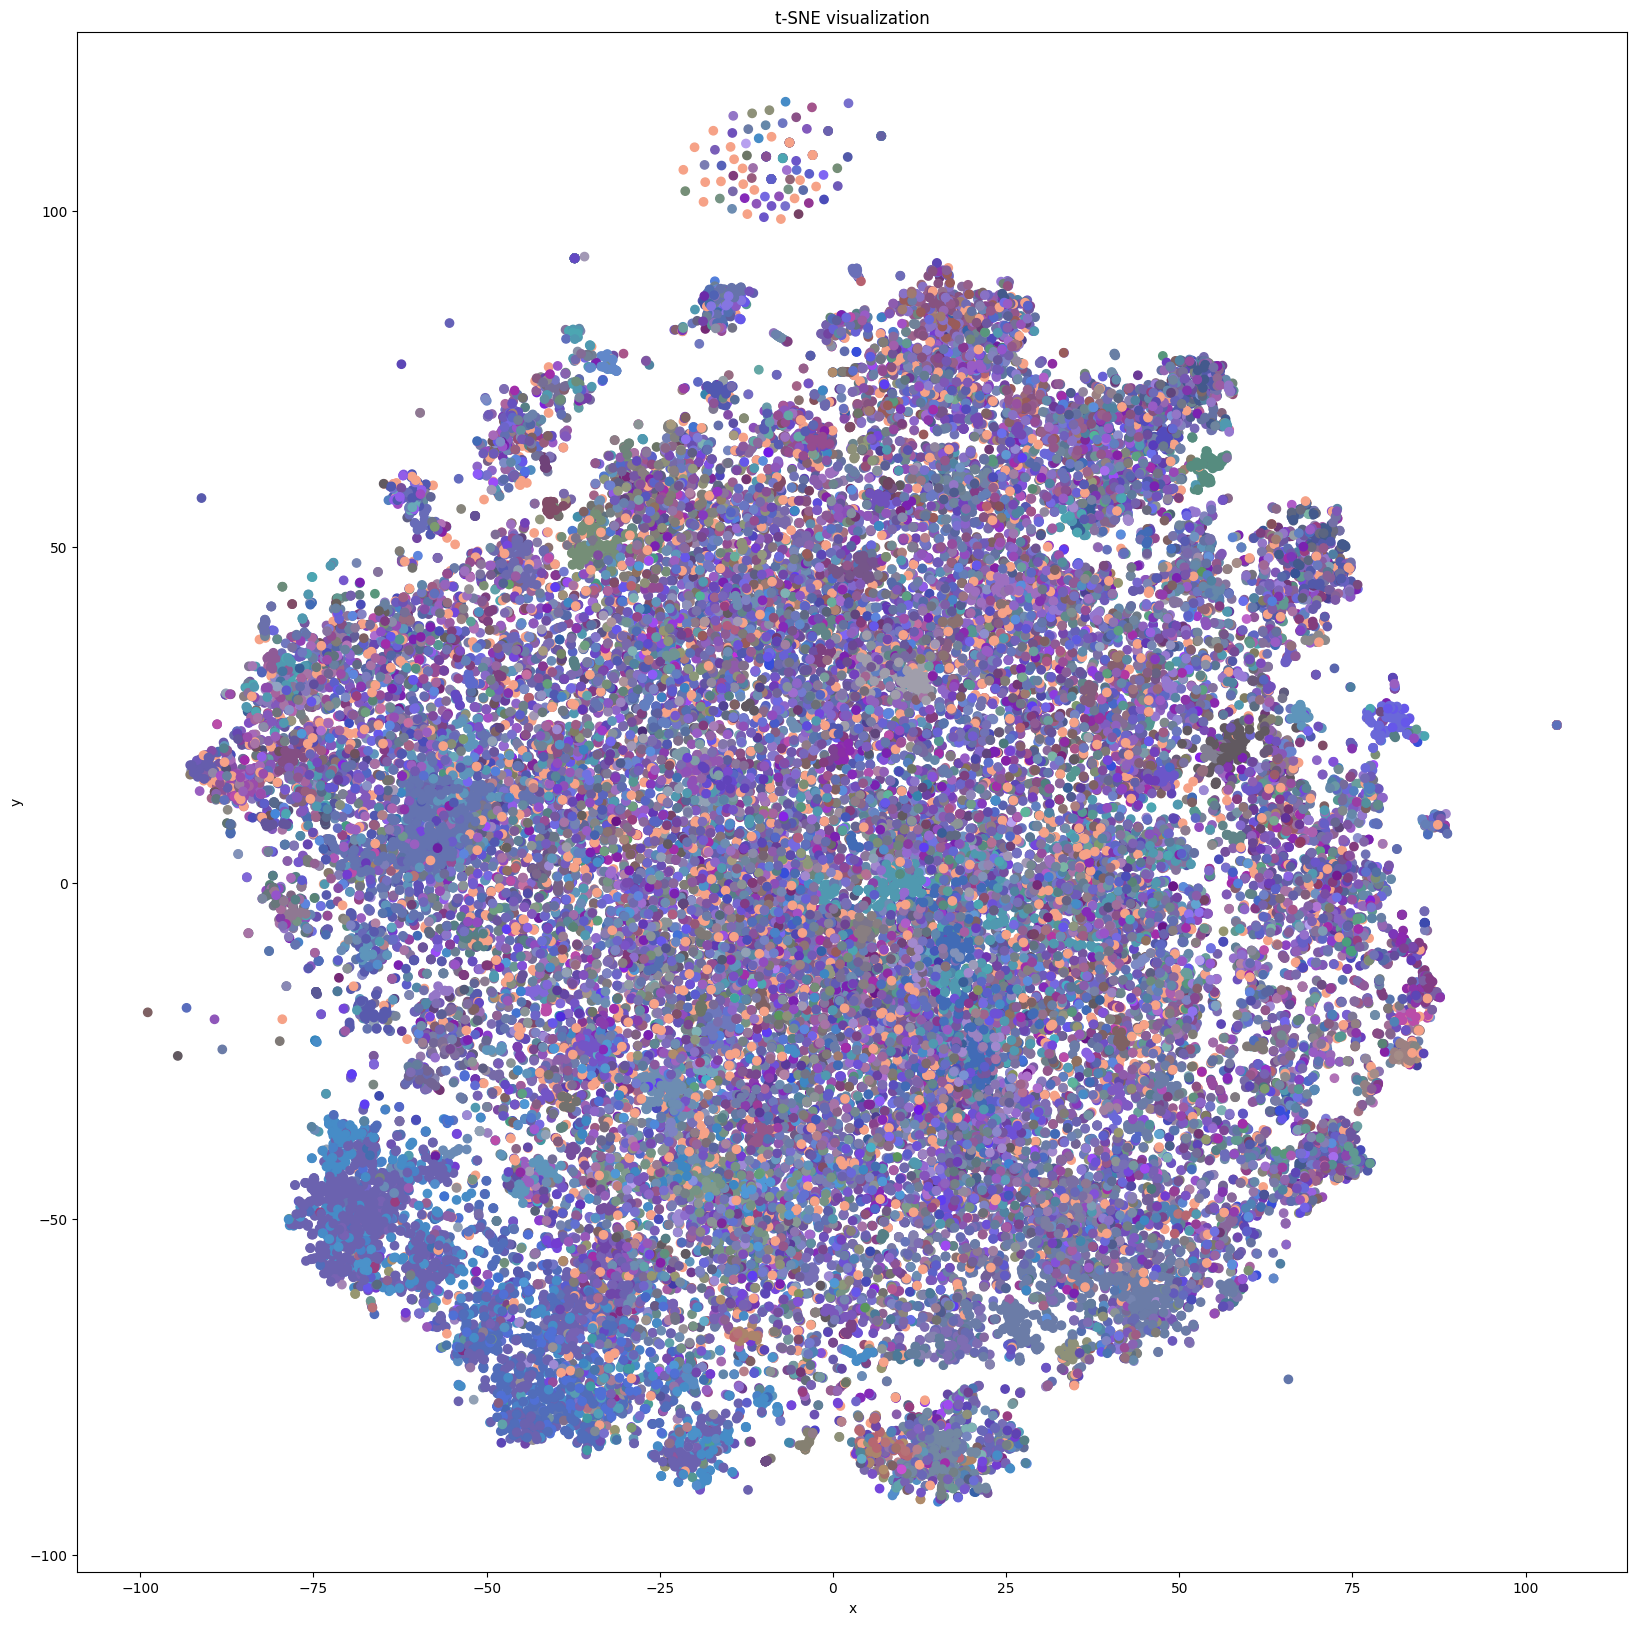

In [9]:
SAMPLE_SIZE = 50000

emb_series = df_emb[df_emb['emb'].notnull()]['emb']

X = np.vstack(emb_series.values)

rand_ind = np.random.choice(range(len(X)), SAMPLE_SIZE, replace=False)
X = X[rand_ind]

X_emb = TSNE(n_components=2, perplexity=32).fit_transform(X)
plt.figure(figsize=(20, 20))
plt.title(f't-SNE visualization')
plt.xlabel('x')
plt.ylabel('y')
plt.scatter(X_emb[:,0], X_emb[:,1], c=df_cat['colour'][rand_ind] / 255.0)
plt.show()